<a href="https://colab.research.google.com/github/DhimanTarafdar/A/blob/main/Simple_RNN_notes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ১. RNN কী এবং কেন এলো — Big Picture

আমরা এর আগে দুটো Neural Network পড়েছি:
- **ANN (Artificial Neural Network)** → Tabular / structured data এর জন্য
- **CNN (Convolutional Neural Network)** → Image, Video এর জন্য
কিন্তু এই দুটো দিয়ে একটা বড় ধরনের data handle করা যাচ্ছিল না — সেটা হলো **Sequential Data**।

এই সমস্যা সমাধানের জন্যই তৈরি হলো তৃতীয় ধরনের Neural Network:

> **RNN (Recurrent Neural Network)** — এটি একটি special class of Neural Network যা specifically **sequential data** এর উপর কাজ করার জন্য design করা হয়েছে।

**"Recurrent" মানে কী?**
Recurrent মানে পুনরাবৃত্তি। RNN এ একই cell বারবার apply হয় — প্রতিটা time step এ। এবং প্রতিবার সে আগের step থেকে তথ্য নিয়ে কাজ করে। এই recurrence বা পুনরাবৃত্তিই এর নামের কারণ।

---

## ২. Sequential Data কী

Sequential data মানে এমন data যেখানে **sequence (ক্রম) matter করে** — মানে কোনটা আগে এলো, কোনটা পরে এলো, সেটা গুরুত্বপূর্ণ।

**উদাহরণ ১ — Text:**
> "আমার নাম রাহুল"

এখানে প্রতিটা word একটার পর একটা আসছে। যদি এলোমেলো করে দেওয়া হয় — "রাহুল নাম আমার" — তাহলে মানে নষ্ট হয়ে যাবে।

**উদাহরণ ২ — Time Series:**
Stock market এর graph দেখো। 2020 সালে কত ছিল, 2021 তে কত হলো — এই ক্রমটা জানলেই বোঝা যায় ভবিষ্যতে কী হতে পারে। ক্রম সরিয়ে দিলে prediction অর্থহীন।

**উদাহরণ ৩ — Audio / Speech:**
তুমি যখন কথা বলছো, সেই sound এর waveform এও sequence আছে। প্রতিটা millisecond এর sound তার আগের এবং পরেরটার সাথে connected।

**উদাহরণ ৪ — Video:**
Video আসলে image এর sequence। Frame 1, Frame 2, Frame 3... — প্রতিটা frame এর মানে বোঝার জন্য আগের frame কী ছিল সেটা জানা দরকার।

**আরও উদাহরণ:** DNA sequence, আবহাওয়ার data।

> **Non-Sequential Data এর উদাহরণ:** একজন student এর CGPA, বয়স, gender দিয়ে placement হবে কি না সেটা predict করা — এখানে কোনো ক্রম নেই, তাই এটা non-sequential। এই কাজে ANN ভালো।

> **সারকথা:** Sequential data সেটাই যেখানে একটা item এর আগে বা পরে কী ছিল সেটা জানা দরকার।

---

## ৩. ANN vs RNN — পার্থক্য কোথায়

| বিষয় | ANN | RNN |
|-------|-----|-----|
| **Data type** | Tabular / fixed-size | Sequential / variable-length |
| **Input** | সব feature একসাথে | এক সময়ে একটা করে |
| **Memory** | নেই | আছে (hidden state) |
| **Time এর ধারণা** | নেই | আছে (time step) |
| **Weight** | আলাদা আলাদা | সব time step এ shared |
| **Architecture** | Feed-forward (সামনের দিকে) | Recurrent (loop আছে) |
| **উপযুক্ত কাজ** | Classification, Regression | NLP, Time series, Speech |

---

## ৪. ANN দিয়ে Sequential Data Handle করা যায় না কেন

এটা বোঝার জন্য একটু ভেবে দেখো — ANN কে যদি text দিতে চাও, তাহলে প্রথমে text কে number এ convert করতে হবে।

### Text কে Vectorize করার পদ্ধতিগুলো

ANN বা যেকোনো Neural Network শুধু number বোঝে। Text কে number এ convert করার সবচেয়ে basic পদ্ধতি: **One-Hot Encoding**

ধরো vocabulary তে ৩টা unique word আছে: [আমি, ভালো, আছি]

| Word | Vector |
|------|--------|
| আমি | [1, 0, 0] |
| ভালো | [0, 1, 0] |
| আছি | [0, 0, 1] |

যদি vocabulary তে **10,000** word থাকে, তাহলে প্রতিটা word হবে **10,000 size** এর vector।

**One-Hot Encoding এর সমস্যা:**
- Vector অনেক বড় হয়ে যায় (sparse vector)
- "রাজা" এবং "রানী" এর মধ্যে কোনো similarity নেই — দুটো সম্পূর্ণ আলাদা vector, অথচ এদের মধ্যে সম্পর্ক আছে
- কোনো semantic meaning নেই
**তাহলে কী করা হয়? → Word Embedding**

Word Embedding এ প্রতিটা word কে একটা **dense, low-dimensional** vector এ map করা হয় যেখানে similar meaning এর word গুলো vector space এ কাছাকাছি থাকে।

```
One-Hot:  "রাজা"  → [0, 0, 1, 0, 0, ..., 0]  (10,000 dimension, বেশিরভাগ 0)
Embedding: "রাজা"  → [0.2, -0.5, 0.8, 0.1]    (মাত্র 4 dimension, সব meaningful)
```

> Embedding এর বিস্তারিত আমরা NLP section এ পড়বো। এখন শুধু জেনে রাখো যে RNN এর আগে সাধারণত Embedding layer থাকে।

---

### ANN তে Sequential Data দিলে কী সমস্যা হয়

#### সমস্যা ১ — Variable Input Size

প্রতিটা sentence এ word সংখ্যা আলাদা:
- "আমার নাম রাহুল" → 3 words
- "আমি ঢাকা বিশ্ববিদ্যালয়ে পড়ি" → 4 words
ANN এর input layer এর size **fixed** থাকে। Variable size input সে নিতে পারে না।

---

#### সমস্যা ২ — Zero Padding এর সমস্যা

একটা জুগাড় solution: সবচেয়ে বড় sentence অনুযায়ী input size fix করো, ছোট গুলোতে শেষে **zero** বসিয়ে সমান করো।

কিন্তু সমস্যা:
- যদি সবচেয়ে বড় sentence এ 100 words, vocabulary 10,000 → input = **10 লাখ**
- Weights হবে কোটিরও বেশি — **অপ্রয়োজনীয় computation**
- Test এ কেউ 200 word এর sentence দিলে কী হবে?
---

#### সমস্যা ৩ — সবচেয়ে বড়: Sequence Information হারিয়ে যায়

ANN তে পুরো sentence এর সব word **একসাথে, একই মুহূর্তে** input হিসেবে ঢোকে।

তাই ANN জানতে পারে না — "ভালো" শব্দটা আগে এসেছিল নাকি পরে।

**ANN এর কোনো memory নেই।** সে বলতে পারে না "আগে X এসেছিল, তারপর Y"।

Text এর মধ্যে যে **semantic meaning** sequence থেকে আসে, ANN সেটা ধরতেই পারে না।

> **উপসংহার:** ANN দিয়ে Sequential data handle করা technically সম্ভব হলেও এটা inefficient, inaccurate এবং by design এই কাজের জন্য তৈরি না।

---

## ৫. RNN কীভাবে এই সমস্যা সমাধান করে — মূল Idea

RNN এর মূল idea টা মানুষের চিন্তার মতোই:

> তুমি যখন একটা বই পড়ো, তুমি প্রতিটা word পড়ো **একটার পর একটা**। আগের word গুলো পড়ে যে context বুঝেছো, সেটা মনে রেখে পরের word বোঝো।

RNN ঠিক এইভাবে কাজ করে:
- **এক সময়ে একটা input নেয়** → variable length এর সমস্যা নেই
- **আগের step এর তথ্য মনে রাখে** → sequence information হারায় না
- **একই weights ব্যবহার করে** → parameter বাড়ে না
এই "মনে রাখার" জিনিসটাকে বলা হয় **Hidden State**।

---

## ৬. RNN এর Architecture এবং Workflow

### মূল Components:

একটা Simple RNN cell এ থাকে:
- **Input (xₜ):** এই time step এর input (যেমন একটা word এর vector)
- **Hidden State (hₜ):** এই step এ network এর "memory" — আগের সব step এর compressed summary
- **Output (yₜ):** এই step এর output
```
        hₜ₋₁ (আগের hidden state)
          │
          ▼
xₜ ──▶ [RNN Cell] ──▶ hₜ (নতুন hidden state)
                │
                ▼
               yₜ (output)
```

### Equations:

```
hₜ = tanh(Wₓ · xₜ + Wₕ · hₜ₋₁ + b)
yₜ = Wᵧ · hₜ + bᵧ
```

**সহজ বাংলায়:**
- নতুন hidden state = (এই step এর input × Wₓ) + (আগের hidden state × Wₕ) + bias → tanh দিয়ে activate করো
- Output = নতুন hidden state × Wᵧ + output bias
### কেন tanh Activation?

RNN এ **tanh** ব্যবহারের কারণ:
- tanh এর output range **-1 থেকে +1** — এটা hidden state কে bounded রাখে
- যদি unbounded হতো, hidden state এর value ক্রমশ বড় হয়ে network অস্থির হয়ে যেত
- tanh এর negative value handle করার ক্ষমতা আছে (ReLU পারে না)
- Gradient flow এর জন্য tanh RNN এ বেশি উপযুক্ত
> তুলনামূলকভাবে — ANN এ ReLU বেশি ব্যবহার হয় কারণ সেখানে hidden state এর concept নেই।

### গুরুত্বপূর্ণ বিষয়:

> **Weights shared হয়।** Wₓ, Wₕ, Wᵧ — এই weight matrix গুলো পুরো sequence জুড়ে **একই** থাকে। প্রতিটা time step এ নতুন weight তৈরি হয় না। এটাই RNN কে efficient করে তোলে।

---

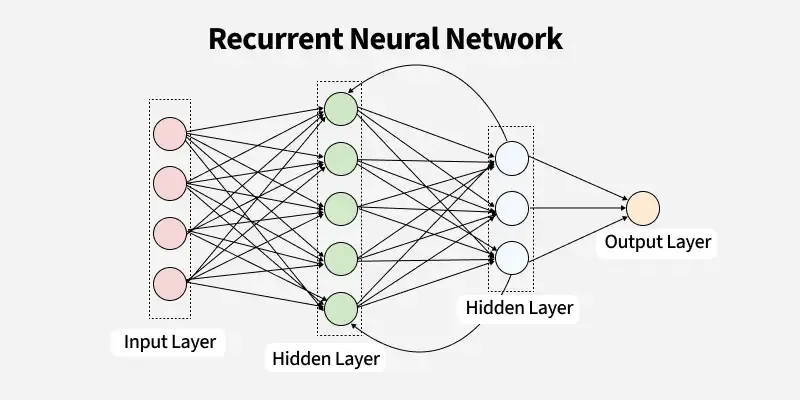

In [10]:
from IPython.display import Image, display
display(Image('/content/recurrent_neural_network.jpg', width=900, height=500))

## ৮. RNN এর Hidden State — Memory কীভাবে কাজ করে

Hidden State হলো RNN এর **"মস্তিষ্ক"** — এটা সব আগের information এর একটা compressed summary।

### উদাহরণ:

ধরো sentence: `"The weather is very"`

RNN এটা process করে এভাবে:

```
h₀ = [0, 0, ..., 0]   ← শুরু, কিছু জানে না

Step 1: x₁ = "The"     → h₁ = tanh(Wₓ·x₁ + Wₕ·h₀ + b)
Step 2: x₂ = "weather" → h₂ = tanh(Wₓ·x₂ + Wₕ·h₁ + b)
Step 3: x₃ = "is"      → h₃ = tanh(Wₓ·x₃ + Wₕ·h₂ + b)
Step 4: x₄ = "very"    → h₄ = tanh(Wₓ·x₄ + Wₕ·h₃ + b)
```

Step 4 এ hidden state h₄ এর মধ্যে "The weather is very" — পুরো context টাই encode হয়ে আছে। তাই পরের word predict করতে পারে যে "cold" বা "hot" আসতে পারে।

> **h₀ (initial hidden state)** সাধারণত সব **zero** দিয়ে শুরু হয়।

**Hidden State এর size কে বলা হয় `hidden_size` বা `hidden_units`।** এটা একটা hyperparameter — তুমি নিজে ঠিক করো। বড় হলে বেশি তথ্য ধরতে পারে, কিন্তু computation বেশি।

---

## ৯. Unfolded RNN — Through Time বোঝো

RNN কে diagram এ সাধারণত **folded** দেখানো হয় — একটা loop এর মতো। কিন্তু এটা বোঝার সহজ উপায় হলো **unfold** করে দেখা।

```
Folded RNN:
        ┌─────┐
xₜ ──▶ │     │──▶ yₜ
        │ RNN │
   ┌──▶ │     │──┐
   │    └─────┘  │ (hidden state loop back করে)
   └─────────────┘


Unfolded RNN (through time):

         x₁           x₂           x₃           x₄
          │            │            │            │
          ▼            ▼            ▼            ▼
h₀ ──▶ [RNN] ──h₁──▶ [RNN] ──h₂──▶ [RNN] ──h₃──▶ [RNN] ──h₄──▶ output
         │            │            │            │
         ▼            ▼            ▼            ▼
        y₁           y₂           y₃           y₄
```

Unfolded করলে দেখা যায়:
- প্রতিটা step এ **একই RNN cell** repeat হচ্ছে (same weights)
- Hidden state বাম থেকে ডানে flow করছে — এটাই memory
- প্রতিটা step আগের step এর উপর নির্ভরশীল
**Gradient কীভাবে যায় (training এ)?**
Training এর সময় gradient ডান থেকে বামে যায়:
```
Loss ← h₄ ← h₃ ← h₂ ← h₁ ← h₀
```
এই process কে বলা হয় **BPTT (Backpropagation Through Time)**।

---

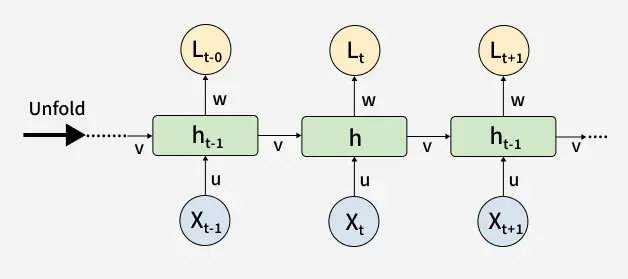

In [8]:
from IPython.display import Image, display
display(Image('/content/nfa1.jpg', width=900, height=500))

## ১০. RNN এর Types — Different Architectures

RNN এর সবচেয়ে গুরুত্বপূর্ণ concept হলো input ও output এর অনুপাত। এটা দিয়েই বিভিন্ন real-world problem solve করা যায়।

### Many-to-One

```
x₁ ──▶ [RNN] ──▶
x₂ ──▶ [RNN] ──▶
x₃ ──▶ [RNN] ──▶ y (একটাই output)
```

- **অনেক input → একটা output**
- শেষ step এর hidden state থেকে একটা output বের হয়
- **উদাহরণ:** Sentiment Analysis (পুরো review পড়ে বলো positive/negative)
---

### One-to-Many

```
x ──▶ [RNN] ──▶ y₁
       [RNN] ──▶ y₂
       [RNN] ──▶ y₃
```

- **একটা input → অনেক output**
- **উদাহরণ:** Image Captioning (একটা image দাও, অনেক word এর caption পাও)
---

### Many-to-Many (Equal Length)

```
x₁ ──▶ [RNN] ──▶ y₁
x₂ ──▶ [RNN] ──▶ y₂
x₃ ──▶ [RNN] ──▶ y₃
```

- **প্রতিটা input এর জন্য একটা output**
- **উদাহরণ:** POS Tagging (প্রতিটা word এর part-of-speech বলো — noun/verb/adjective)
---

### Many-to-Many (Encoder-Decoder)

```
Encoder:                    Decoder:
x₁ ──▶ [RNN] ──▶            ──▶ [RNN] ──▶ y₁
x₂ ──▶ [RNN] ──▶ [context]  ──▶ [RNN] ──▶ y₂
x₃ ──▶ [RNN] ──▶            ──▶ [RNN] ──▶ y₃
```

- Input ও output এর length আলাদা হতে পারে
- **উদাহরণ:** Machine Translation (বাংলা → English, word সংখ্যা মিলবে না)
- প্রথমে Encoder পুরো input process করে একটা **context vector** তৈরি করে, তারপর Decoder সেটা থেকে output generate করে
---

## ১১. Trainable Parameters কীভাবে Calculate করবে

Simple RNN এ মোট ৩ ধরনের weight matrix থাকে:

| Weight | কী করে | Size |
|--------|--------|------|
| **Wₓ** (Input weight) | input → hidden | (input_size × hidden_size) |
| **Wₕ** (Hidden weight) | hidden → hidden | (hidden_size × hidden_size) |
| **Wᵧ** (Output weight) | hidden → output | (hidden_size × output_size) |
| **b** (Hidden bias) | — | (hidden_size) |
| **bᵧ** (Output bias) | — | (output_size) |

### উদাহরণ Calculation:

ধরো:
- `input_size = 4` (4 feature)
- `hidden_size = 3` (3 hidden units)
- `output_size = 2` (2 class output)
```
Wₓ  = 4 × 3 = 12
Wₕ  = 3 × 3 = 9
b   = 3
Wᵧ  = 3 × 2 = 6
bᵧ  = 2

মোট parameters = 12 + 9 + 3 + 6 + 2 = 32
```

> **মনে রাখো:** এই weight গুলো পুরো sequence জুড়ে **share** হয়, তাই sequence লম্বা হলেও parameter বাড়ে না — এটাই RNN এর সৌন্দর্য।

**ANN এর সাথে তুলনা:** ANN এ প্রতিটা layer এর আলাদা আলাদা weight থাকে। RNN এ একই weight বারবার ব্যবহার হয়।

---

## ১২. একটা Simple Dataset দিয়ে Trainable Parameters Verify করো (PyTorch)


In [1]:
import torch
import torch.nn as nn

In [2]:
class RNNModel(nn.Module):
  def __init__(self):
    #register kora
    super(RNNModel,self).__init__()
    self.rnn = nn.RNN(input_size=5,hidden_size=3,batch_first=True)
    self.fc = nn.Linear(3,1)
    self.sigmoid = nn.Sigmoid()


  def forward(self,x):
    out , _ = self.rnn(x)
    out = out[:,-1,:]
    out = self.fc(out)
    out = self.sigmoid(out)
    return out


In [3]:
model = RNNModel()

In [4]:
# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)



RNNModel(
  (rnn): RNN(5, 3, batch_first=True)
  (fc): Linear(in_features=3, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


---

## ১৩. RNN এ Input কীভাবে দেওয়া হয় — Shape বোঝো

PyTorch এ RNN এ input দেওয়ার format (`batch_first=True` হলে):

```
Input shape: (batch_size, sequence_length, input_size)
```

**উদাহরণ:**
- `batch_size = 32` → একসাথে 32টা sentence process হচ্ছে
- `sequence_length = 10` → প্রতিটা sentence এ 10টা word
- `input_size = 50` → প্রতিটা word এর embedding size 50
```python
# Dummy data তৈরি করো
x = torch.randn(32, 10, 50)  # (batch, seq_len, input_size)

rnn = nn.RNN(input_size=50, hidden_size=64, batch_first=True)

output, hidden = rnn(x)

print(output.shape)   # → (32, 10, 64)  ← প্রতিটা time step এর output
print(hidden.shape)   # → (1, 32, 64)   ← শেষ step এর hidden state
```

**Output shape বোঝো:**
- `output (32, 10, 64)` → 32টা sentence, প্রতিটায় 10টা step, প্রতিটা step এ 64 dimensional output
- `hidden (1, 32, 64)` → 1 layer, 32 sentence, 64 hidden units — এটা সবচেয়ে শেষ step এর hidden state
**কখন কোনটা ব্যবহার করবো?**
- **Many-to-One** (Sentiment Analysis) → শুধু `hidden` নাও — পুরো sequence পড়ার পর শেষ state
- **Many-to-Many** (POS Tagging) → `output` নাও — প্রতিটা step এর output দরকার
---

## ১৪. BPTT — Backpropagation Through Time (Basic Intuition)

RNN কীভাবে train হয়? ANN এর মতোই backpropagation — কিন্তু এখানে time এর উপর দিয়ে করতে হয়।

### Basic Idea:

```
Forward pass:  h₀ → h₁ → h₂ → h₃ → h₄ → Loss
Backward pass: Loss → h₄ → h₃ → h₂ → h₁ → h₀
```

**Gradient কীভাবে যায়:**
- প্রথমে Loss থেকে শেষ step এর gradient বের করা হয়
- তারপর সেই gradient আগের step এ পাঠানো হয়
- এভাবে একদম শুরু পর্যন্ত চলে
**কেন "Through Time" বলা হয়:**
- ANN এ gradient যায় layer এর মধ্য দিয়ে
- RNN এ gradient যায় time step এর মধ্য দিয়ে — তাই "Through Time"
**Weight update:**
যেহেতু সব time step এ same weights ব্যবহার হয়, প্রতিটা step থেকে যে gradient আসে সেগুলো **যোগ করে** একবারে weights update করা হয়।

> বিস্তারিত BPTT calculation আমরা পরের note এ পড়বো।

---

## ১৫. RNN এর Applications

RNN কোথায় কোথায় কাজে লাগে:

### ১. Sentiment Analysis (Many-to-One)
- **Input:** একটা text review
- **Output:** Positive / Negative / Neutral
- **উদাহরণ:** Amazon এর product review analyze করে rating predict করা
### ২. Next Word / Sentence Completion (Many-to-One / Many-to-Many)
- **Input:** "আমি বাংলাদেশে..."
- **Output:** পরের word predict করা
- **উদাহরণ:** Gmail Smart Compose, ফোনের keyboard suggestion
### ৩. Machine Translation (Many-to-Many Encoder-Decoder)
- **Input:** বাংলা sentence
- **Output:** English sentence
- **উদাহরণ:** Google Translate এর পুরনো version
### ৪. Image Captioning (One-to-Many)
- CNN দিয়ে image থেকে feature বের করো → RNN দিয়ে caption generate করো
- **উদাহরণ:** "A man is riding a bicycle on a road"
### ৫. Speech Recognition (Many-to-Many)
- Audio waveform → Text (প্রতিটা audio frame sequential input)
- **উদাহরণ:** Siri, Google Assistant এর speech-to-text
### ৬. Time Series Forecasting (Many-to-One / Many-to-Many)
- **উদাহরণ:** আগের 30 দিনের stock price দিয়ে আগামীকালের price predict করা
### ৭. Named Entity Recognition / POS Tagging (Many-to-Many)
- প্রতিটা word এর জন্য একটা label predict করো
- **উদাহরণ:** "রাহুল ঢাকায় থাকেন" → [Person, Location, Verb]
---

## ১৬. RNN এর Limitations — Vanishing & Exploding Gradient

RNN অনেক কাজ করতে পারলেও একটা বড় সমস্যা আছে — **Long Sequence** এ ভালো কাজ করে না।

### সমস্যাটা কোথায়?

RNN train হওয়ার সময় BPTT ব্যবহার হয়। এই process এ gradient কে time এর পিছনে পিছনে propagate করতে হয়।

প্রতিটা step এ gradient কে একটা সংখ্যা দিয়ে multiply করতে হয়।

---

### Vanishing Gradient

যদি সেই সংখ্যাটা **১ এর চেয়ে ছোট** হয় (যেমন 0.5):

```
Step 10: gradient = 1.0
Step 9:  gradient = 0.5
Step 8:  gradient = 0.25
Step 7:  gradient = 0.125
Step 6:  gradient = 0.0625
...
Step 1:  gradient ≈ 0.001  ← প্রায় শূন্য!
```

**ফলাফল:** Network এর শুরুর দিকের weights update হয় না → **Long-term dependency শিখতে পারে না।**

**Real উদাহরণ:**
> "The **cat** that sat on the mat and played with the toy... **was** happy."

এখানে "was" এর subject "cat" অনেক আগে ছিল। Vanishing gradient এর কারণে RNN "cat" আর "was" এর সম্পর্ক ধরতে পারে না।

---

### Exploding Gradient

যদি সেই সংখ্যাটা **১ এর চেয়ে বড়** হয় (যেমন 1.5):

```
Step 1: gradient = 1.0
Step 2: gradient = 1.5
Step 3: gradient = 2.25
Step 4: gradient = 3.375
...    (exponentially বাড়তে থাকে)
```

Gradient অনেক বড় হয়ে যায় → Weights বিশাল আকারে update হয় → **Model diverge করে — NaN আসে।**

---

### সমাধান কী?

| সমস্যা | সমাধান | কীভাবে কাজ করে |
|--------|--------|----------------|
| Vanishing Gradient | **LSTM** | Gate mechanism দিয়ে কোন তথ্য রাখবে, কোনটা ভুলবে সেটা শেখে |
| Vanishing Gradient | **GRU** | LSTM এর সহজ version, কম parameter |
| Exploding Gradient | **Gradient Clipping** | Gradient এর maximum value একটা threshold এ clip করে রাখে |

```python
# Gradient Clipping উদাহরণ
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
```

> এই সমস্যাগুলো সমাধান করতেই LSTM এবং GRU তৈরি হয়েছে — যা আমরা পরের note এ পড়বো।

---